### Загрузка и обработка данных

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import arch.unitroot as au
from scipy.stats import friedmanchisquare
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.tsa.ardl import ARDL, ardl_select_order
import sys
import os
os.environ['RPY2_CFFI_MODE'] = 'ABI'
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
import itertools
import math
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from scipy.stats import chi2, f
from statsmodels.tsa.x13 import x13_arima_analysis
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, globalenv
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects.conversion import localconverter
import rpy2.rinterface_lib.callbacks
import os
import pickle
from statsmodels.tsa.x13 import x13_arima_analysis
import tempfile
import uuid
from typing import Dict, List, Tuple
import re

import panel_utils
from panel_utils import (
    detect_outlier_regions_iqr,
    friedman_seasonality_test,
    run_panel_unit_root_tests,
    seasonal_adjust_panel_series,
    run_friedman_seasonality_tests,
)


In [2]:
###############################
    #ЗАГРУЗКА + ПРЕДОБРАБОТКА ДАННЫХ
###############################
df_RF = pd.read_excel('База данных_рег и фед показатели.xlsx', skiprows=1, sheet_name = 'data_RF')
df_reg = pd.read_excel('База данных_рег и фед показатели.xlsx',skiprows=1 , sheet_name = 'data')
households_structure = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=1, sheet_name = 'Фин пол ДХ')
households_loans = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', sheet_name = 'КЖН (рейтинг)')
funds_coefficient = pd.read_excel('База_соц_эконом_неоднор_регионов.xlsx', skiprows=2, sheet_name = 'Коэф фондов')
pickle_filename = 'region_cluster_dataset.pkl'
# df_roisfix = pd.read_excel('roisfix.xlsx') # скорректированный ROISFIX из Тейлора
# df_roisfix = df_roisfix.drop(columns=['Unnamed: 0'])
with open(pickle_filename, 'rb') as f:
    df_region_cluster = pickle.load(f)

# Преобразование даты 
df_RF['Date'] = pd.to_datetime(df_RF['Date'])
df_RF = df_RF.sort_values('Date')
df_reg['Date'] = pd.to_datetime(df_reg['Date'])
df_reg = df_reg.sort_values(['Num_reg','Date'])

In [3]:
###############################
# АНАЛИЗ ПАНЕЛЬНЫХ ДАННЫХ
###############################
pickle_filename = 'mon_shock_dataset.pkl'
with open(pickle_filename, 'rb') as f:
    df_shocks = pickle.load(f)
df_shocks['Date'] = pd.to_datetime(df_shocks['Date'])

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

df_reg['Date'] = pd.to_datetime(df_reg['Date'])

#  ДОБАВЛЯЕМ КЛАСТЕРЫ 
df_reg = df_reg.merge(df_region_cluster, on='Region', how='left')

# ============ ФЕДЕРАЛЬНЫЕ ПЕРЕМЕННЫЕ ============
df_reg = df_reg.merge(df_shocks[['Date', 'Mon_Shock']], on='Date', how='left')

df_rf_extra = df_RF[['Date', 'Bonds_Rate_Correct_5Y', 'Inflation_Expectations', 'exc_rate', 'MIACR', 'Covid_dum', 'Sank_dum', 'ROISFIX']].copy()
df_reg = df_reg.merge(df_rf_extra, on='Date', how='left')
df_reg.rename(columns={'exc_rate': 'Exc_rate'}, inplace=True)

# Создаем лаги
df_reg['Int_Rate_FL_lag1'] = df_reg.groupby('Region')['Int_Rate_FL'].shift(1)
df_reg['Int_Rate_Mort_lag1'] = df_reg.groupby('Region')['Int_Rate_Mort'].shift(1)
df_reg['Int_Rate_ConsCred_lag1'] = df_reg.groupby('Region')['Int_Rate_ConsCred'].shift(1)



In [4]:
###############################################
### Переход к первым разностям панельных данных
###############################################

##############################
# Разности переменных регионов
##############################

# Разность кредитов физлиц и потреб кредитов
df_reg['d_Int_Rate_FL'] = df_reg.groupby('Region')['Int_Rate_FL'].diff()
df_reg['d_Int_Rate_Mort'] = df_reg.groupby('Region')['Int_Rate_Mort'].diff()
df_reg['d_Int_Rate_ConsCred'] = df_reg.groupby('Region')['Int_Rate_ConsCred'].diff()

# Разделим Mon_Shock на позитивный и негативный
df_reg['Mon_Shock_neg'] = df_reg['Mon_Shock'].where(df_reg['Mon_Shock'] < 0, 0)
df_reg['Mon_Shock_pos'] = df_reg['Mon_Shock'].where(df_reg['Mon_Shock'] > 0, 0)

# Разность монетарного шока
df_reg['d_Mon_Shock'] = df_reg.groupby('Region')['Mon_Shock'].diff()
df_reg['d_Mon_Shock_neg'] = df_reg.groupby('Region')['Mon_Shock_neg'].diff()
df_reg['d_Mon_Shock_pos'] = df_reg.groupby('Region')['Mon_Shock_pos'].diff()



#################################
# Разности федеральных переменных
#################################

df_RF = df_RF.sort_values(['Date'])

df_RF['d_CPI'] = df_RF['CPI'].diff()
df_RF['d_Key_Rate'] = df_RF['Key_Rate'].diff()
df_RF['d_Ex_Rate'] = df_RF['exc_rate_diff']

In [5]:
# СПИСОК ПЕРЕМЕННЫХ
conscred_vars = [
    'd_Int_Rate_ConsCred',          # Зависимая переменная
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',       # Лаг зависимой
    'New_Loans_ConsCred',           # Выдача
    'New_Loans_ConsCred_mom',
    'New_Loans_Fl',
    'New_Loans_Fl_mom',
    'Zadolg_ConsCred',              # Задолженность
    'Zadolg_ConsCred_mom', 
    'Zadolg_Fl',
    'Zadolg_Fl_mom',
    'Def_Zadolg_ConsCred',          # Дефицит задолж
    'Def_Zadolg_Fl',
    'Cred_nagr',                    # Переменные состояния финансового рынка
    'Fin_Dostup',
    'D_top5_rozn',
    'Zakred',
    'Exc_rate',                     # Переменные ожиданий
    'Bonds_Rate_Correct_5Y',
    'Inflation_Expectations',
    #
    'Mon_Shock',                    # Шоки
    'd_Mon_Shock',
    'Mon_Shock_neg',
    'Mon_Shock_pos',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'ROISFIX',
    'MIACR',
    'Covid_dum',                    # Дамми
    'Sank_dum',
    'Cluster_1',
    'Cluster_2',
]


other_vars = [
    'Int_Rate_FL',
    'Int_Rate_FL_lag1',
    'Int_Rate_Mort',
    'Credit_impulse',
    'Int_Rate_Mort_lag1',
    'Int_Rate_ConsCred',
    'Int_Rate_ConsCred_lag1',
    'Cred_nagr',
    'D_top5_rozn',
    'Fin_Dostup',
    'Cred_structure',
    'Def_Zadolg_Fl',
    'Def_Zadolg_Mort',
    'Def_Zadolg_ConsCred',
    'Mon_Shock',
    'Exc_rate',
    'Inflation_Expectations',
    'Bonds_Rate_Correct_5Y',
    'Cluster_1',
    'Cluster_2',
    'New_Loans_Progr',
    'MIACR',
    'Covid_dum',
    'Sank_dum',
    'ROISFIX'
]

choosed_vars = conscred_vars

df_reg_analys = df_reg[['Region', 'Date'] + choosed_vars].copy()
df_reg_analys = df_reg_analys[df_reg_analys['Region'] != 'Москва']
cols_for_drop = [c for c in df_reg_analys.columns if c not in ['New_Loans_Progr']]
df_reg_analys = df_reg_analys.dropna(subset=cols_for_drop)

### IQR чистка

In [6]:
print("\n" + "="*70)
print("ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR")
print("="*70)

key_vars = [x for x in choosed_vars if x not in [
    'Mon_Shock',                    # Шоки
    'd_Mon_Shock',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'd_Mon_Shock_neg',
    'd_Mon_Shock_pos',
    'ROISFIX',
    'MIACR',
    'Cluster_1',
    'Cluster_2',
    'Covid_dum',
    'Sank_dum',
    ]
]


# АНАЛИЗ РЕГИОНОВ ПО IQR
region_quality_iqr = detect_outlier_regions_iqr(df_reg_analys, key_vars, min_obs=60, max_na_pct=0.3)

print(f"\n АНАЛИЗ {len(region_quality_iqr)} РЕГИОНОВ (IQR)")
print(region_quality_iqr.to_string(index=False))

# СТАТИСТИКА
exclude_count = len(region_quality_iqr[region_quality_iqr['Status'] == 'EXCLUDE'])
keep_count = len(region_quality_iqr) - exclude_count

print(f"\n СТАТИСТИКА:")
print(f"Всего регионов: {len(region_quality_iqr)}")
print(f"Исключено: {exclude_count} ({exclude_count/len(region_quality_iqr)*100:.1f}%)")
print(f"Оставлено: {keep_count}")

# СПИСОК ХОРОШИХ РЕГИОНОВ
good_regions_iqr = region_quality_iqr[region_quality_iqr['Status'] == 'KEEP']['Region'].tolist()

# ФИЛЬТРАЦИЯ ДАННЫХ
df_reg_analys= df_reg_analys[df_reg_analys['Region'].isin(good_regions_iqr)].copy()
print(f"\n Форма после очистки (IQR): {df_reg_analys.shape}")





ОЧИСТКА РЕГИОНОВ ПО МЕТОДУ IQR

 АНАЛИЗ 85 РЕГИОНОВ (IQR)
                                              Region  N_obs NA_pct  IQR_outliers IQR_pct                       Reasons  Status
                                Белгородская область     77   0.0%            13   16.9%                                  KEEP
                                    Брянская область     77   0.0%            14   18.2%                                  KEEP
                                Владимирская область     77   0.0%            12   15.6%                                  KEEP
                                 Воронежская область     77   0.0%            13   16.9%                                  KEEP
                                  Ивановская область     77   0.0%            13   16.9%                                  KEEP
                                    Тверская область     77   0.0%            12   15.6%                                  KEEP
                                   Калужская область

### ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ

In [7]:
descriptive_df = df_reg_analys.drop(columns=['Date', 'Region', 'Int_Rate_ConsCred_lag1'], axis = 1, inplace=False)


desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])


ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
                             Среднее       Медиана     ст. откл.         Мин.  \
d_Int_Rate_ConsCred     1.550000e-01 -2.000000e-03  2.202000e+00      -69.779   
Int_Rate_ConsCred       1.807300e+01  1.595500e+01  5.626000e+00       11.504   
New_Loans_ConsCred      1.626291e+07  1.013932e+07  1.912209e+07   198014.288   
New_Loans_ConsCred_mom  2.138000e+00  2.749000e+00  1.428600e+01      -59.029   
New_Loans_Fl            2.133110e+07  1.295965e+07  2.542451e+07   257616.254   
New_Loans_Fl_mom        2.393000e+00  3.841000e+00  1.636300e+01      -53.424   
Zadolg_ConsCred         1.650673e+08  1.015734e+08  1.839130e+08  3588654.740   
Zadolg_ConsCred_mom     8.030000e-01  9.950000e-01  1.393000e+00       -6.821   
Zadolg_Fl               3.234663e+08  1.964714e+08  3.929925e+08  7187278.270   
Zadolg_Fl_mom           1.054000e+00  1.182000e+00  1.136000e+00       -4.717   
Def_Zadolg_ConsCred     7.524000e+00  7.527000e+00  1.43

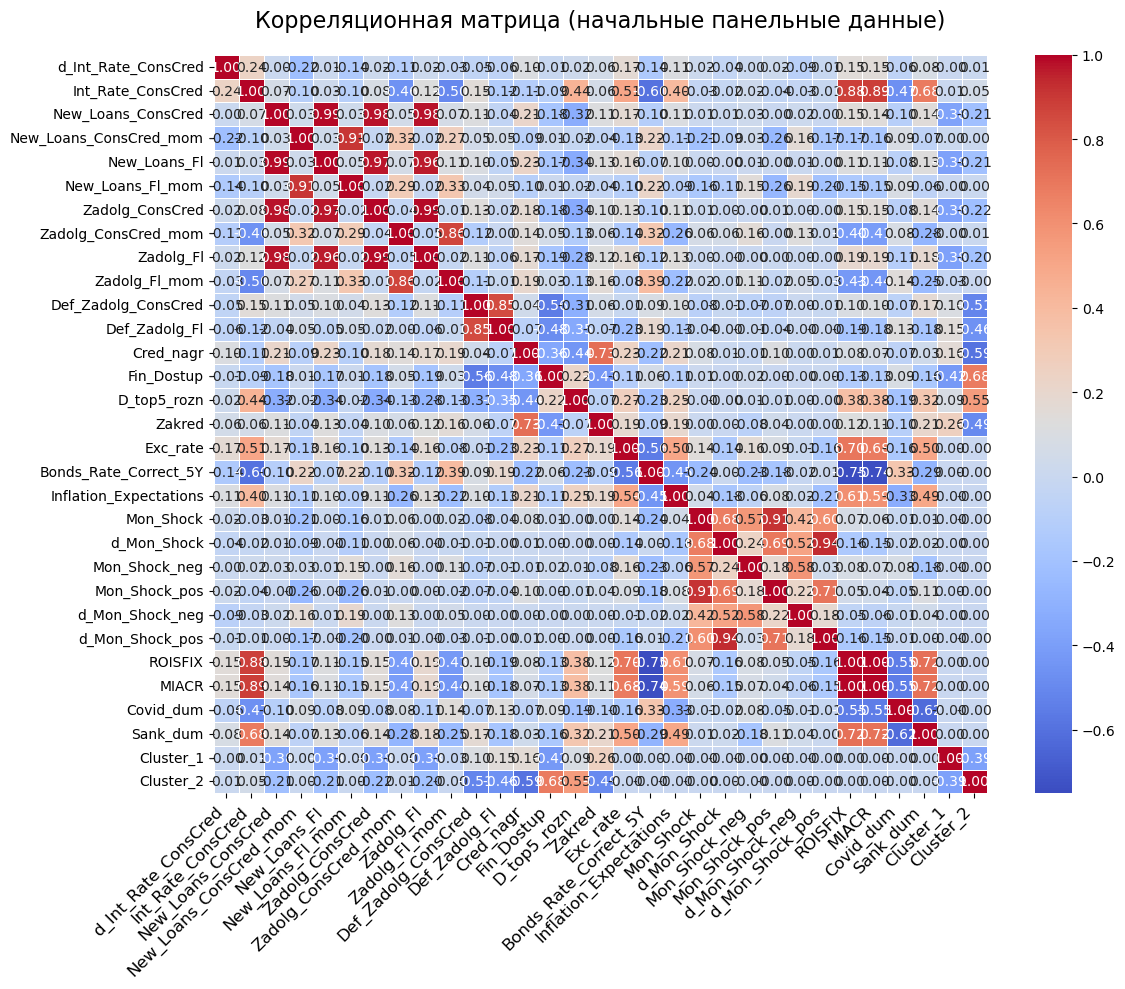

In [8]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ИСХОДНЫЕ ПАНЕЛЬНЫЕ ДАННЫЕ
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (начальные панельные данные)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

### Тест Фридмана на сезонность

In [9]:
friedman_summary = panel_utils.run_friedman_seasonality_tests(df_RF, date_col='Date')

c:\Users\donat\anaconda3\envs\Credit\Lib\site-packages\scipy\stats\_stats_py.py:8780: RuntimeWarning: invalid value encountered in scalar divide
  statistic = (12.0 / (k*n*(k+1)) * ssbn - 3*n*(k+1)) / c



РЕЗУЛЬТАТЫ ТЕСТОВ ФРИДМАНА
                  Variable  Chi_Squared      P_Value  Has_Seasonality  N_Years  N_Months
                   Num_reg          NaN          NaN            False        5        12
             CAR_Indicator    12.107692 3.556030e-01            False        5        12
              D_Progr_mort    11.707692 3.860113e-01            False        5        12
                   ROISFIX     4.456963 9.545978e-01            False        5        12
                  exc_rate    15.276923 1.701670e-01            False        5        12
             exc_rate_diff    17.892308 8.411333e-02            False        5        12
     Bonds_Rate_Correct_5Y     3.800000 9.754064e-01            False        5        12
    Inflation_Expectations    21.442254 2.906820e-02             True        5        12
      Nominal_Percent_Rate    11.863422 3.739965e-01            False        5        12
       Ent_conf_ind_mining    21.098503 3.236478e-02             True        5    

In [10]:
# # Extra diagnostics after Friedman test
# from panel_utils import run_seasonal_diagnostics

# series_list = [
#     'Inflation_Expectations',
#     'Ent_conf_ind_mining',
#     'Ent_conf_ind_manufactoring'
# ]

# for col in series_list:
#     if col in df_RF.columns:
#         run_seasonal_diagnostics(df_RF, 'Date', col, shock_year="2022")
#     else:
#         print(f'Missing column: {col}')


# # ####################################
# # # Сезонность есть даже с учётом шока в: Inflation_Expectations, Ent_conf_ind_manufactoring

### ===== СЕЗОННАЯ КОРРЕКТИРОВКА ДЛЯ ПАНЕЛЬНЫХ ДАННЫХ =====


СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Инфляционные ожидания (Inflation_Expectations):
  ✓ Успешно скорректировано, снижение волатильности: 2.0%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ
✓ Inflation_Expectations_adj: 3003 не-NaN значений
✓ Inflation_Expectations_trend: 3003 не-NaN значений
✓ Inflation_Expectations_seasonal: 3003 не-NaN значений

✓ Всего добавлено столбцов: 3

СВОДКА РЕЗУЛЬТАТОВ СЕЗОННОЙ КОРРЕКТИРОВКИ

Федеральные переменные:
--------------------------------------------------
Переменная                     Волатильность ↓
--------------------------------------------------
Инфляционные ожидания                     2.0%


Региональные переменные (среднее по регионам):
--------------------------------------------------
Переменная                     Волатильность ↓
--------------------------------------------------

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ (ПРИМЕРЫ)

Графики федеральных переменных...


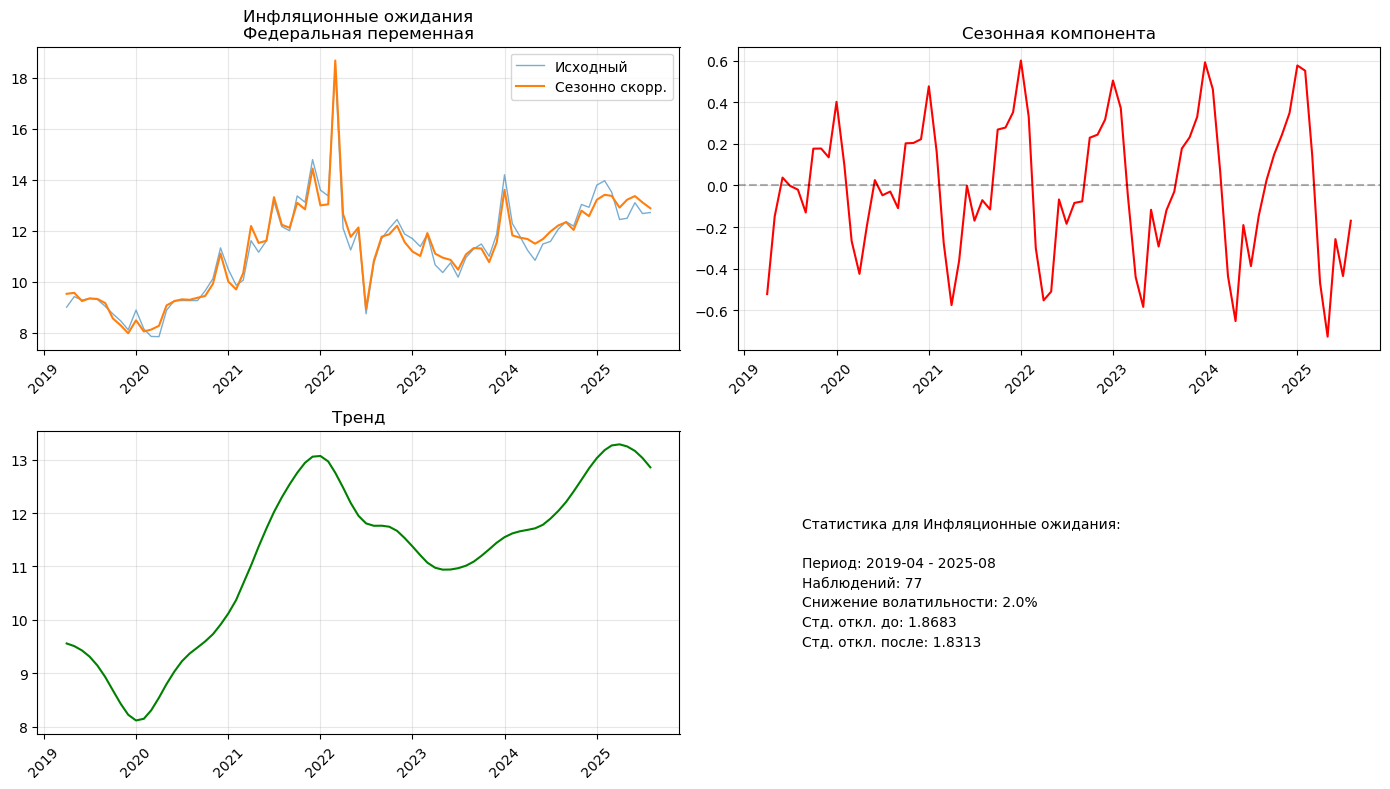


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 1/1
Обработано региональных переменных: 0/0
Общее количество добавленных столбцов: 3
Форма df: (3003, 37)

Столбцов _adj: 1
Столбцов _trend: 1
Столбцов _seasonal: 1

✓ Скорректированные ряды добавлены в df
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)

СЕЗОННАЯ КОРРЕКТИРОВКА ФЕДЕРАЛЬНЫХ ПЕРЕМЕННЫХ

Ent_conf_ind_manufactoring (Ent_conf_ind_manufactoring):
  ✓ Успешно скорректировано, снижение волатильности: 5.8%

Ent_conf_ind_mining (Ent_conf_ind_mining):
  ✓ Успешно скорректировано, снижение волатильности: 8.6%

СЕЗОННАЯ КОРРЕКТИРОВКА РЕГИОНАЛЬНЫХ ПЕРЕМЕННЫХ

ПРОВЕРКА ДОБАВЛЕННЫХ СТОЛБЦОВ
✓ Ent_conf_ind_manufactoring_adj: 81 не-NaN значений
✓ Ent_conf_ind_manufactoring_trend: 81 не-NaN значений
✓ Ent_conf_ind_manufactoring_seasonal: 81 не-NaN значений
✓ Ent_conf_ind_mining_adj: 81 не-NaN значений
✓ Ent_conf_ind_mining_trend: 81 не-NaN значений
✓ Ent_conf_ind_mining_seasonal: 81 не-NaN значений

✓ Всего

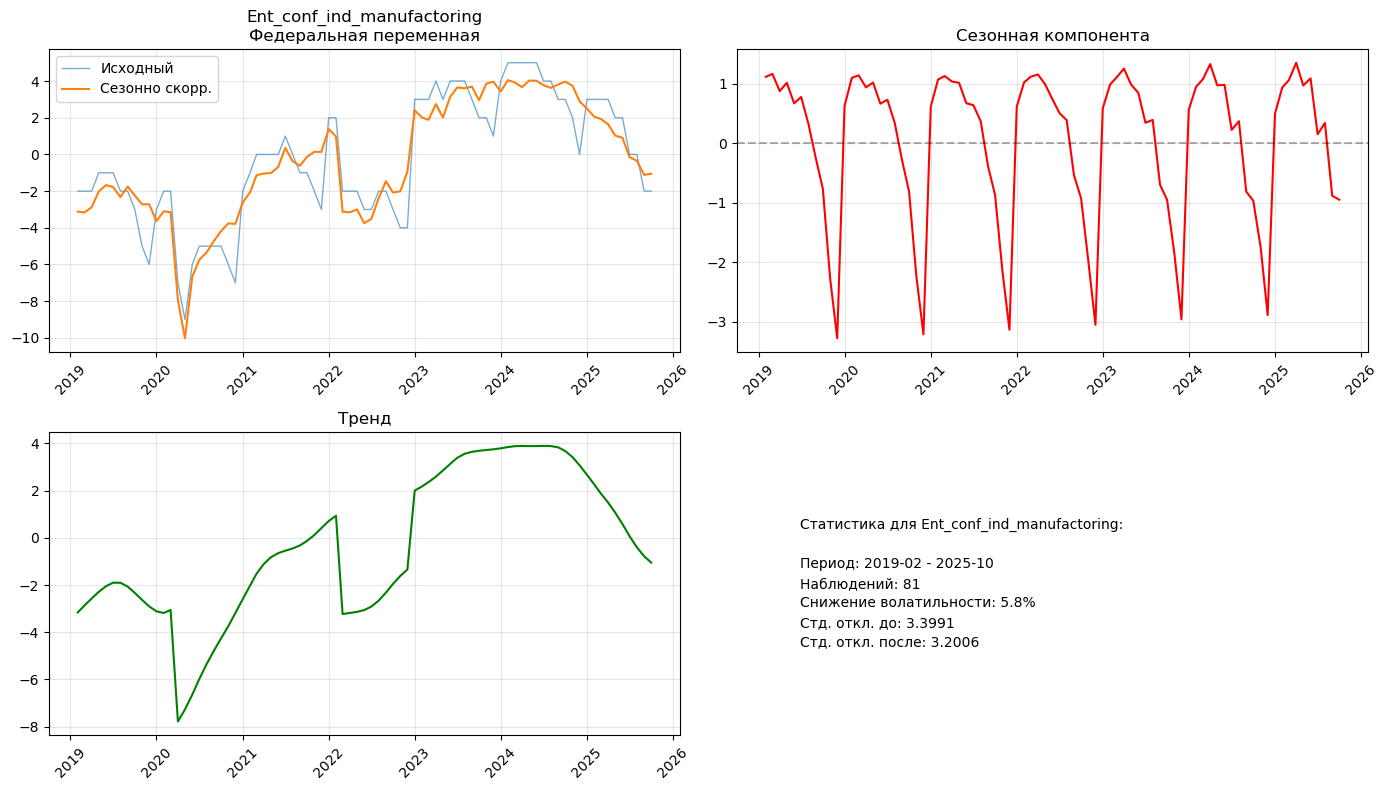

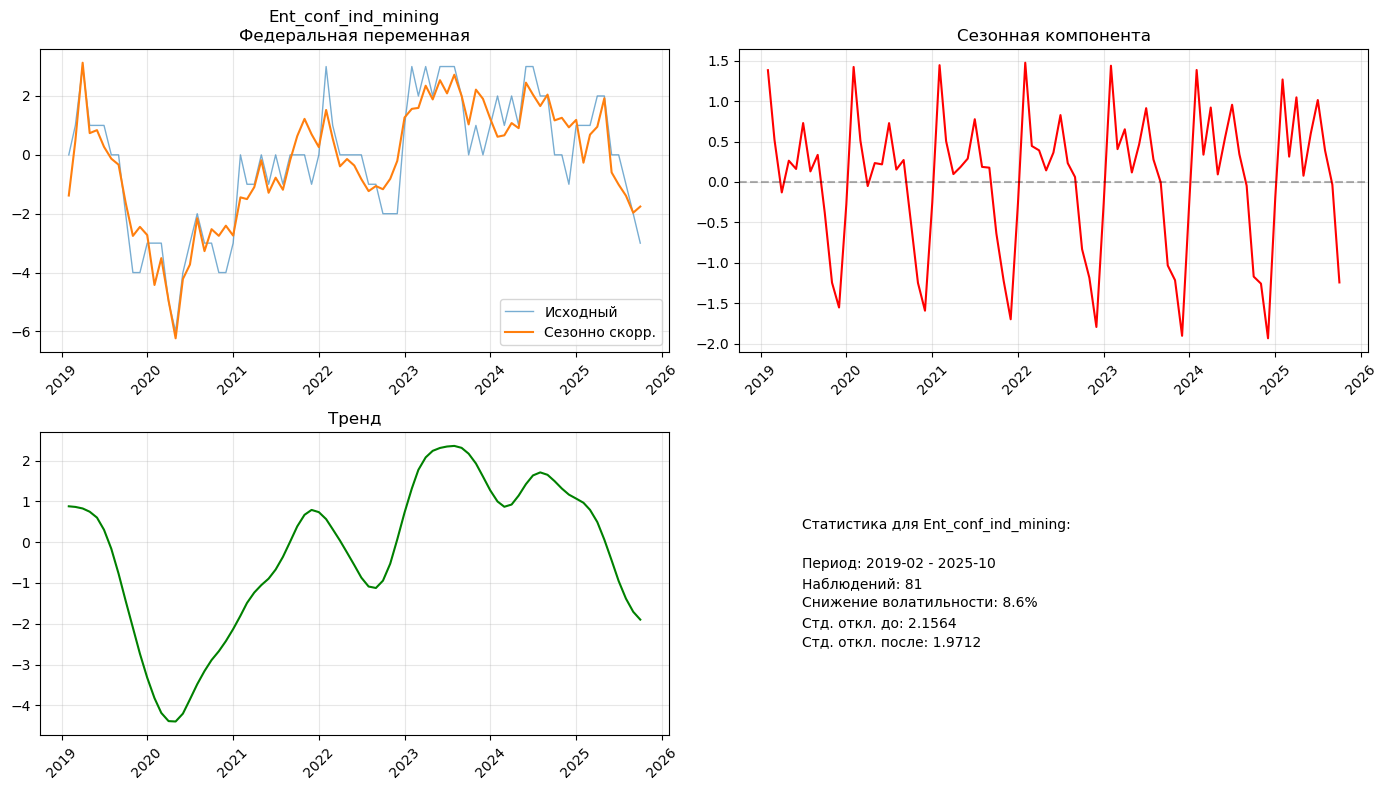


ФИНАЛЬНАЯ СТАТИСТИКА

Обработано федеральных переменных: 2/2
Обработано региональных переменных: 0/0
Общее количество добавленных столбцов: 6
Форма df: (81, 35)

Столбцов _adj: 2
Столбцов _trend: 2
Столбцов _seasonal: 2

✓ Скорректированные ряды добавлены в df
✓ Столбцы с суффиксами: _adj (скорр.), _trend (тренд), _seasonal (сезон)


In [11]:
# Сезонная корректировка 
# 'Inflation_Expectations', 'Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining' потенциальные переменные

from seasonal_adjustment import seasonal_adjust_panel_wrapper

col_name = ['Inflation_Expectations'] 
df_reg_analys = seasonal_adjust_panel_wrapper(df_reg_analys, col_name)

col_name = ['Ent_conf_ind_manufactoring', 'Ent_conf_ind_mining'] 
df_RF = seasonal_adjust_panel_wrapper(df_RF, col_name)


In [12]:
# Чистка датафрейма
to_delete_columns_reg = [col for col in df_reg_analys.columns if col.endswith('_seasonal') or col.endswith('_trend')]
to_delete_columns_RF = [col for col in df_RF.columns if col.endswith('_seasonal') or col.endswith('_trend')]

df_reg_analys.drop(columns=to_delete_columns_reg, inplace=True)
df_RF.drop(columns=to_delete_columns_RF, inplace=True)

# Разность инфляционных ожиданий
df_reg_analys['d_Inflation_Expectations'] = df_reg_analys['Inflation_Expectations_adj'].diff()

### Tестирование единичных корней

In [13]:
# ===== ЗАПУСК ТЕСТОВ НА КОНКРЕТНЫЕ ПЕРЕМЕННЫЕ =====

print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1")
print("="*70)

# === СПИСОК ПЕРЕМЕННЫХ ДЛЯ ТЕСТИРОВАНИЯ ===
custom_vars = [x for x in choosed_vars if x not in [
    'Cluster_1',
    'Cluster_2',
    'Covid_dum',
    'Sank_dum']
]

df_reg_analys_clus_1 = df_reg_analys[df_reg_analys['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_1, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ - КЛАСТЕР 1
Тестирование 28 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_ConsCred
  2. Int_Rate_ConsCred
  3. Int_Rate_ConsCred_lag1
  4. New_Loans_ConsCred
  5. New_Loans_ConsCred_mom
  6. New_Loans_Fl
  7. New_Loans_Fl_mom
  8. Zadolg_ConsCred
  9. Zadolg_ConsCred_mom
  10. Zadolg_Fl
  11. Zadolg_Fl_mom
  12. Def_Zadolg_ConsCred
  13. Def_Zadolg_Fl
  14. Cred_nagr
  15. Fin_Dostup
  16. D_top5_rozn
  17. Zakred
  18. Exc_rate
  19. Bonds_Rate_Correct_5Y
  20. Inflation_Expectations
  21. Mon_Shock
  22. d_Mon_Shock
  23. Mon_Shock_neg
  24. Mon_Shock_pos
  25. d_Mon_Shock_neg
  26. d_Mon_Shock_pos
  27. ROISFIX
  28. MIACR

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
            Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_Stationarity
   d_Int_Ra

In [14]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2")
print("="*70)


df_reg_analys_clus_two = df_reg_analys[df_reg_analys['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_two, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 2
Тестирование 28 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_ConsCred
  2. Int_Rate_ConsCred
  3. Int_Rate_ConsCred_lag1
  4. New_Loans_ConsCred
  5. New_Loans_ConsCred_mom
  6. New_Loans_Fl
  7. New_Loans_Fl_mom
  8. Zadolg_ConsCred
  9. Zadolg_ConsCred_mom
  10. Zadolg_Fl
  11. Zadolg_Fl_mom
  12. Def_Zadolg_ConsCred
  13. Def_Zadolg_Fl
  14. Cred_nagr
  15. Fin_Dostup
  16. D_top5_rozn
  17. Zakred
  18. Exc_rate
  19. Bonds_Rate_Correct_5Y
  20. Inflation_Expectations
  21. Mon_Shock
  22. d_Mon_Shock
  23. Mon_Shock_neg
  24. Mon_Shock_pos
  25. d_Mon_Shock_neg
  26. d_Mon_Shock_pos
  27. ROISFIX
  28. MIACR

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
            Переменная  Hadri_Stat  Hadri_PValue  LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall_

In [15]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3")
print("="*70)

df_reg_analys_clus_three = df_reg_analys[(df_reg_analys['Cluster_1'] == 0) & (df_reg_analys['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_reg_analys_clus_three, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - КЛАСТЕР 3
Тестирование 28 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_ConsCred
  2. Int_Rate_ConsCred
  3. Int_Rate_ConsCred_lag1
  4. New_Loans_ConsCred
  5. New_Loans_ConsCred_mom
  6. New_Loans_Fl
  7. New_Loans_Fl_mom
  8. Zadolg_ConsCred
  9. Zadolg_ConsCred_mom
  10. Zadolg_Fl
  11. Zadolg_Fl_mom
  12. Def_Zadolg_ConsCred
  13. Def_Zadolg_Fl
  14. Cred_nagr
  15. Fin_Dostup
  16. D_top5_rozn
  17. Zakred
  18. Exc_rate
  19. Bonds_Rate_Correct_5Y
  20. Inflation_Expectations
  21. Mon_Shock
  22. d_Mon_Shock
  23. Mon_Shock_neg
  24. Mon_Shock_pos
  25. d_Mon_Shock_neg
  26. d_Mon_Shock_pos
  27. ROISFIX
  28. MIACR

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
            Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overall

In [16]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted_all = run_panel_unit_root_tests(df_reg_analys, panel_vars=custom_vars)


ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ НАЧАЛЬНЫХ ПЕРЕМЕННЫХ - ВСЕ ДАННЫЕ
Тестирование 28 переменных на единичные корни
Переменные для тестирования:
  1. d_Int_Rate_ConsCred
  2. Int_Rate_ConsCred
  3. Int_Rate_ConsCred_lag1
  4. New_Loans_ConsCred
  5. New_Loans_ConsCred_mom
  6. New_Loans_Fl
  7. New_Loans_Fl_mom
  8. Zadolg_ConsCred
  9. Zadolg_ConsCred_mom
  10. Zadolg_Fl
  11. Zadolg_Fl_mom
  12. Def_Zadolg_ConsCred
  13. Def_Zadolg_Fl
  14. Cred_nagr
  15. Fin_Dostup
  16. D_top5_rozn
  17. Zakred
  18. Exc_rate
  19. Bonds_Rate_Correct_5Y
  20. Inflation_Expectations
  21. Mon_Shock
  22. d_Mon_Shock
  23. Mon_Shock_neg
  24. Mon_Shock_pos
  25. d_Mon_Shock_neg
  26. d_Mon_Shock_pos
  27. ROISFIX
  28. MIACR

РЕЗУЛЬТАТЫ ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ
            Переменная  Hadri_Stat  Hadri_PValue   LLC_Stat   LLC_PValue   PP_Mean  PP_Median  PP_Rejections_%  DFGLS_Mean  DFGLS_Median  DFGLS_Rejections_%  Hadri_Stationarity  LLC_Stationarity  PP_Stationarity  DFGLS_Stationarity  Overal

### Сохранение результатов

In [17]:
df_reg_analys.to_excel('cons_reg_analys.xlsx')
df_RF.to_excel('fed_analys.xlsx')

### С логарифмированием переменных выдач

In [ ]:
###############################
# Переход к первым разностям панельных данных
# С логарифмированием переменных выдач
###############################
df_reg = df_reg_analys.copy()

if isinstance(df_reg.index, pd.MultiIndex):
    df_reg = df_reg.reset_index()

# ============ ЛОГАРИФМИРОВАНИЕ ВЫДАЧ ============

loan_vars = ['New_Loans_Fl_adj', 'New_Loans_Mort_adj', 'New_Loans_ConsCred_adj', 'MIACR', 'New_Loans_Progr']

for var in loan_vars:
    if var in df_reg.columns:
        df_reg[f'ln_{var}'] = np.log(df_reg[var])

# ============ СОЗДАНИЕ ПЕРВЫХ РАЗНОСТЕЙ ТОЛЬКО ДЛЯ НЕСТАЦИОНАРНЫХ ПЕРЕМЕННЫХ ============

exclude_cols = ['Region', 'Date']

# список скорректированных переменных, для которых тесты показали нестационарность
nonstat_vars = results_seasonal_adjusted.loc[
    results_seasonal_adjusted['Overall_Stationarity'] == False,  # нестационарные
    'Переменная'].tolist()

# защитимся от случая, если в results есть переменные, которых уже нет в df_reg
nonstat_vars = [v for v in nonstat_vars if v in df_reg.columns]

# логарифмы выдач
ln_loan_vars = [f'ln_{var}' for var in loan_vars if f'ln_{var}' in df_reg.columns]

# обычные переменные, для которых нужно строить разности:
#  - только нестационарные
#  - исключаем служебные, логарифмы и уже существующие d_
initial_vars = [
    col for col in nonstat_vars
    if col not in exclude_cols
    and not col.startswith('d_')
    and not col.startswith('ln_')
]

# Разности для обычных нестационарных переменных
for var in initial_vars:
    df_reg[f'd_{var}'] = df_reg.groupby('Region')[var].diff()

# Разности для логарифмов выдач (их всегда дифференцируем, как раньше)
for var in ln_loan_vars:
    d_var = f'd_{var}'
    df_reg[d_var] = df_reg.groupby('Region')[var].diff()

# ============ ПРОВЕРКА СОЗДАННЫХ СТОЛБЦОВ ============

d_cols = [col for col in df_reg.columns if col.startswith('d_')]

exog_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj', 
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'ln_New_Loans_Progr',
    'd_ln_MIACR',
    'Covid_dum',
    'Sank_dum',
    'd_ln_ROISFIX'
]

# Проверяем, какие переменные реально существуют
exog_vars_existing = [var for var in exog_vars if var in df_reg.columns]
exog_vars_missing = [var for var in exog_vars if var not in df_reg.columns]

df_exog = df_reg[['Region', 'Date'] + exog_vars_existing].copy()
cols_to_check = [c for c in df_exog.columns if c != 'ln_New_Loans_Progr']
df_exog = df_exog.dropna(subset=cols_to_check)

In [ ]:
df_exog.head()

In [ ]:
df_exog.info()

In [ ]:
df_exog.to_excel('exog.xlsx')

In [ ]:
#df_exog = pd.read_excel('exog.xlsx')

In [ ]:
###############################
# ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
descriptive_df = df_exog[[
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',  
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'Mon_Shock',
    'd_Exc_rate_adj',
    'Cluster_1',
    'Cluster_2',
    'Covid_dum',
    'Sank_dum',
    'ln_New_Loans_Progr'
]]

desc = descriptive_df.describe().round(3).T

medians = descriptive_df.median()
desc['median'] = medians.round(3)

desc = desc.rename(columns={
    'mean': 'Среднее',
    'median': 'Медиана',
    'std': 'ст. откл.',
    'min': 'Мин.',
    'max': 'Макс.',
})

print("\n" + "="*60)
print("ОПИСАТЕЛЬНЫЕ СТАТИСТИКИ - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА")
print("="*60)
print(desc[['Среднее', 'Медиана', 'ст. откл.', 'Мин.', 'Макс.']])

In [ ]:
###############################
# КОРРЕЛЯЦИОННАЯ МАТРИЦА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ - ОБЩАЯ ВЫБОРКА
###############################
dd = descriptive_df.corr()
plt.figure(figsize=(12, 10))
fig = sns.heatmap(dd, annot=True,
                  fmt=".2f",
                  linewidth=0.5,
                  linecolor='white',
                  annot_kws={"size": 10},
                  cmap='coolwarm')

fig.set_title("Корреляционная матрица (панельные данные в первых разностях - общая выборка)",
             fontsize=16, pad=20)

fig.set_xticklabels(fig.get_xticklabels(),
                   rotation=45,
                   ha='right',
                   fontsize=12)

plt.tight_layout()

In [ ]:
###############################
    #Добавление дополнительных переменных
###############################

# Кластеры * монетарный шок
df_exog['Mon_Shock_Cl1'] = df_exog['Mon_Shock'] * df_exog['Cluster_1']
df_exog['Mon_Shock_Cl2'] = df_exog['Mon_Shock'] * df_exog['Cluster_2']

# Кластеры * d_ln_ROISFIX
df_exog['d_ln_ROISFIX_Cl1'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_1']
df_exog['d_ln_ROISFIX_Cl2'] = df_exog['d_ln_ROISFIX'] * df_exog['Cluster_2']

# Кластеры * d_ln_MIACR
df_exog['d_ln_MIACR_Cl1'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_1']
df_exog['d_ln_MIACR_Cl2'] = df_exog['d_ln_MIACR'] * df_exog['Cluster_2']

# Covid * переменные интреса
df_exog['Mon_Shock_Covid']   = df_exog['Mon_Shock']   * df_exog['Covid_dum']
df_exog['d_ln_ROISFIX_Covid'] = df_exog['d_ln_ROISFIX'] * df_exog['Covid_dum']
df_exog['d_ln_MIACR_Covid']   = df_exog['d_ln_MIACR']   * df_exog['Covid_dum']

# Санкции * переменные интреса
df_exog['Mon_Shock_Sanctions']   = df_exog['Mon_Shock']   * df_exog['Sank_dum']
df_exog['d_ln_ROISFIX_Sanctions'] = df_exog['d_ln_ROISFIX'] * df_exog['Sank_dum']
df_exog['d_ln_MIACR_Sanctions']   = df_exog['d_ln_MIACR']   * df_exog['Sank_dum']


In [ ]:
df_exog.info()

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 1 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 1")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 2 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 2")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 3 спецификация
###############################

vif_variables = [
    'd_Int_Rate_FL_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()
X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 3")
print("="*60) 
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 4 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 4")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 5 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 5")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 6 спецификация
###############################

vif_variables = [
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 6")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 7 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 7")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 8 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Covid'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 8")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 9 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'Covid_dum',
    'Sank_dum',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 9")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 10 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr'

]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #VIF-анализ - панельные данные спецификация в первых разностях 11 спецификация
###############################

vif_variables = [
    'd_Int_Rate_Mort_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'Credit_impulse_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Mort_adj',
    'Mon_Shock',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj',
    'Inflation_Expectations_adj',
    'ln_New_Loans_Progr',
    'Mon_Shock_Cl1',
    'Mon_Shock_Cl2'
]

df_vif = df_exog[vif_variables].copy()
df_vif = df_vif.dropna()

X_vif = sm.add_constant(df_vif[vif_variables])

# Расчет VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = vif_variables
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i+1) for i in range(len(vif_variables))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ VIF АНАЛИЗА - ПАНЕЛЬНЫЕ ДАННЫЕ В ПЕРВЫХ РАЗНОСТЯХ СПЕЦИФИКАЦИЯ 10")
print("="*60)
print(vif_data.to_string(index=False))

In [ ]:
###############################
    #Тест на стационарность I(1) рядов для 1-го кластера
###############################

custom_vars = [
    'd_Int_Rate_FL_adj',
    'd_Int_Rate_FL_lag1_adj',
    'd_Int_Rate_Mort_adj',
    'Credit_impulse_adj',
    'd_Int_Rate_Mort_lag1_adj',
    'd_Int_Rate_ConsCred_adj',
    'd_Int_Rate_ConsCred_lag1_adj',
    'd_Cred_nagr_adj',
    'd_D_top5_rozn_adj',
    'd_Fin_Dostup_adj',
    'd_Cred_structure_adj',
    'd_Def_Zadolg_Fl_adj',
    'd_Def_Zadolg_Mort_adj',
    'd_Def_Zadolg_ConsCred_adj',
    'Inflation_Expectations_adj',
    'd_Bonds_Rate_Correct_5Y_adj',
    'd_Exc_rate_adj'
]
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ")
print("="*70)
# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 1")
print("="*70)

df_exog_clus_one = df_exog[df_exog['Cluster_1'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_one, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 2")
print("="*70)

df_exog_clus_two = df_exog[df_exog['Cluster_2'] == 1].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_two, panel_vars=custom_vars)

In [ ]:
print("\n" + "="*70)
print("ЗАПУСК ТЕСТОВ НА ЕДИНИЧНЫЕ КОРНИ ДЛЯ I(1) РЯДОВ - КЛАСТЕР 3")
print("="*70)

df_exog_clus_three = df_exog[(df_exog['Cluster_1'] == 0) & (df_exog['Cluster_2'] == 0)].copy()

# Запуск функции с пользовательским списком переменных
results_seasonal_adjusted = run_panel_unit_root_tests(df_exog_clus_three, panel_vars=custom_vars)

In [ ]:
df_exog_clus_one.info()

In [ ]:
df_exog_clus_two.info()

In [ ]:
df_exog_clus_three.info()